In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

**Contexto**

El conjunto de datos se compone de información recopilada de camiones pesados ​​Scania durante su uso cotidiano. El sistema objeto de estudio es el sistema de aire a presión (APS), el cual genera aire comprimido utilizado para diversas funciones del camión, tales como el frenado y el cambio de marchas. La clase positiva del conjunto de datos comprende los fallos de un componente específico del sistema APS, mientras que la clase negativa incluye camiones con fallos en componentes ajenos a dicho sistema.

El conjunto de entrenamiento contiene un total de 60.000 ejemplos, de los cuales 59.000 pertenecen a la clase negativa y 1.000 a la clase positiva. El conjunto de prueba contiene 16.000 ejemplos. Hay 171 atributos por registro.

Los nombres de los atributos de los datos han sido anonimizados por razones de propiedad. Estos consisten tanto en contadores numéricos individuales como en histogramas formados por intervalos (o *bins*) con diferentes condiciones. Por lo general, los histogramas presentan condiciones de rango abierto en ambos extremos. Por ejemplo, si se mide la temperatura ambiente "T", el histograma podría definirse con 4 intervalos donde:

Los atributos son los siguientes: la clase, seguida de datos operativos anonimizados. Los datos operativos cuentan con un identificador y un identificador de intervalo, con el formato "Identificador_Intervalo". En total hay 171 atributos, de los cuales 7 son variables de histograma. Los valores faltantes se indican mediante "na".

**Inspiración**

El costo total de un modelo de predicción es la suma del Costo_1 multiplicado por el número de instancias con fallas de tipo 1 y el Costo_2 multiplicado por el número de instancias con fallas de tipo 2, lo que resulta en un Costo_Total. En este caso, el Costo_1 se refiere al costo de una revisión innecesaria realizada por un mecánico en un taller, mientras que el Costo_2 se refiere al costo de no detectar un camión defectuoso, lo que podría causar una avería. Costo_1 = 10 y Costo_2 = 500, y Costo_Total = Costo_1 * Número_de_Instancias + Costo_2 * Número_de_Instancias.

In [4]:
train = pd.read_csv(r'C:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\TP\aps_failure_training_set.csv', skiprows=20, na_values='na')
test = pd.read_csv(r'C:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\TP\aps_failure_test_set.csv', skiprows=20, na_values='na')

In [5]:
train.shape

(60000, 171)

In [6]:
test.shape

(16000, 171)

In [7]:
from sklearn.impute import SimpleImputer

# cd_000 es constante (unico valor no nulo) -> no aporta info, se descarta
train = train.drop(columns=['cd_000'])
test  = test.drop(columns=['cd_000'])

feature_cols = train.columns.drop('class')
imputer = SimpleImputer(strategy='median')
train[feature_cols] = imputer.fit_transform(train[feature_cols])
test[feature_cols] = imputer.transform(test[feature_cols])


In [8]:
train.shape

(60000, 170)

In [9]:
threshold = 0.9

# corremos la correlacion sobre las variables continuas originales, sin 'class'
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# de cada par con |r| > threshold, nos quedamos con una y descartamos la otra
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f'Columnas eliminadas por alta correlacion (> {threshold}): {len(to_drop)} de {len(feature_cols)}')
print(to_drop)

train = train.drop(columns=to_drop)
test  = test.drop(columns=to_drop)

print('shape train:', train.shape, 'shape test:', test.shape)


Columnas eliminadas por alta correlacion (> 0.9): 43 de 169
['am_0', 'an_000', 'ao_000', 'aq_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bt_000', 'bu_000', 'bv_000', 'by_000', 'cc_000', 'cf_000', 'ci_000', 'cn_004', 'cn_005', 'co_000', 'cq_000', 'cs_005', 'dc_000', 'dn_000', 'dp_000', 'dt_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004']
shape train: (60000, 127) shape test: (16000, 127)


In [10]:
train.shape

(60000, 127)

In [11]:
test.shape

(16000, 127)

In [17]:
X_train_full = train.drop(columns='class')
y_train_full = train['class'].map({'neg': 0, 'pos': 1})

X_test = test.drop(columns='class')
y_test = test['class'].map({'neg': 0, 'pos': 1})


In [18]:
X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape

((60000, 126), (60000,), (16000, 126), (16000,))

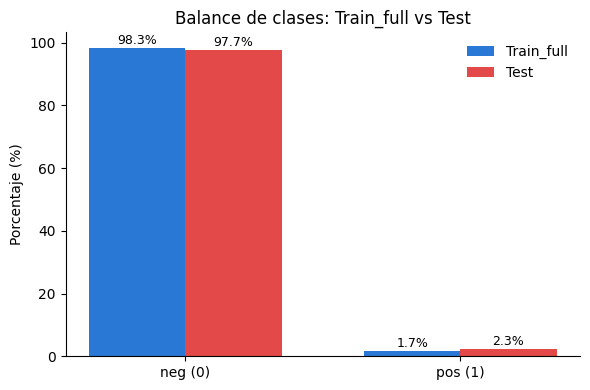

In [20]:
counts_train = y_train_full.value_counts(normalize=True).sort_index() * 100
counts_test  = y_test.value_counts(normalize=True).sort_index() * 100

labels = ['neg (0)', 'pos (1)']
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_train = ax.bar([i - width/2 for i in x], counts_train.values, width, label='Train_full', color='#2a78d6')
bars_test  = ax.bar([i + width/2 for i in x], counts_test.values, width, label='Test', color='#e34948')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Balance de clases: Train_full vs Test')
ax.legend(frameon=False)

for bars in [bars_train, bars_test]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.1f}%', xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a dividir el X_train_full y el y_train_full en un set de train y otro de validacion

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,  # importante por el desbalance
    random_state=42
)

In [22]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((48000, 126), (48000,), (12000, 126), (12000,))

### Vamos a aplicar un BASELINE

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# Opción 1: predice siempre la clase mayoritaria (neg)
baseline_majority = DummyClassifier(strategy="most_frequent")

# Opción 2: predice respetando la proporción de clases del train
baseline_stratified = DummyClassifier(strategy="stratified", random_state=42)

for name, clf in [("most_frequent", baseline_majority), ("stratified", baseline_stratified)]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred, digits=3))

most_frequent
              precision    recall  f1-score   support

           0      0.977     1.000     0.988     15625
           1      0.000     0.000     0.000       375

    accuracy                          0.977     16000
   macro avg      0.488     0.500     0.494     16000
weighted avg      0.954     0.977     0.965     16000

stratified
              precision    recall  f1-score   support

           0      0.977     0.984     0.981     15625
           1      0.036     0.024     0.029       375

    accuracy                          0.962     16000
   macro avg      0.506     0.504     0.505     16000
weighted avg      0.955     0.962     0.958     16000



c:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\Repositorio\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\Repositorio\aprMaqI_CEIA\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\Repositorio\aprMaqI_CEIA\.venv\Lib\site-packag

### Vamos a aplicar Regresion Logistica

##### Busqueda de hiperparametros

In [24]:
clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced", {0: 1, 1: 50}, {0: 1, 1: 30}]
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1)
grid.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=5000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [25]:
grid.best_params_

{'model__C': 0.1,
 'model__class_weight': None,
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

elegidos los parametros corremos el modelo

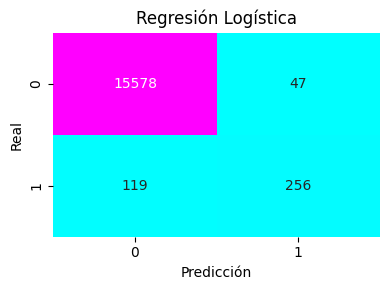

In [26]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [27]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")

Regresión Logística
Sensibilidad (Recall): 0.6827
Especificidad:         0.9970
Exactitud balanceada:  0.8398
Precisión:             0.8449
Recall:                0.6827
F1-score:              0.7552


In [30]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.01, 0.10, 0.01):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

   umbral  FN   FP  costo
0    0.01   9  729  11790
1    0.02  12  358   9580
2    0.03  20  274  12740
3    0.04  24  228  14280
4    0.05  27  193  15430
5    0.06  27  177  15270
6    0.07  27  160  15100
7    0.08  31  148  16980
8    0.09  32  137  17370

Mejor umbral:
umbral       0.02
FN          12.00
FP         358.00
costo     9580.00
Name: 1, dtype: float64


In [31]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.010, 0.030, 0.001):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN   FP  costo
0    0.010   9  729  11790
1    0.011   9  644  10940
2    0.012  10  583  10830
3    0.013  10  533  10330
4    0.014  11  493  10430
5    0.015  11  468  10180
6    0.016  11  442   9920
7    0.017  12  423  10230
8    0.018  12  397   9970
9    0.019  12  379   9790
10   0.020  12  358   9580
11   0.021  12  349   9490
12   0.022  12  337   9370
13   0.023  13  328   9780
14   0.024  16  321  11210
15   0.025  16  310  11100
16   0.026  17  306  11560
17   0.027  19  297  12470
18   0.028  19  286  12360
19   0.029  19  281  12310

Mejor umbral:
umbral       0.022
FN          12.000
FP         337.000
costo     9370.000
Name: 12, dtype: float64


In [32]:
probs_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
umbral_final = 0.022
y_pred_test = (probs_test >= umbral_final).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_final = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final en test: {costo_final}")
print(classification_report(y_test, y_pred_test, digits=3))

TN=15226, FP=399, FN=27, TP=348
Costo final en test: 17490
              precision    recall  f1-score   support

           0      0.998     0.974     0.986     15625
           1      0.466     0.928     0.620       375

    accuracy                          0.973     16000
   macro avg      0.732     0.951     0.803     16000
weighted avg      0.986     0.973     0.978     16000

